<a href="https://colab.research.google.com/github/hridibazaman03/220142_ANN/blob/main/220142_ANN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [39]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    roc_curve,
    roc_auc_score
)

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

import warnings
warnings.filterwarnings('ignore')

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cpu


In [40]:
url = "https://raw.githubusercontent.com/hridibazaman03/220142_ANN/main/heart.csv"

df = pd.read_csv(url)

print(df.shape)
df.head()

(1025, 14)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [41]:
#Data exploration

print(df.info())

print("\nMissing Values")
print(df.isnull().sum())

print("\nClass Distribution")
print(df['target'].value_counts())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB
None

Missing Values
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0

In [42]:
#Data processing

target_col = 'target'

X = df.drop(target_col, axis=1)
y = df[target_col]

categorical_cols = X.select_dtypes(include=['object']).columns.tolist()

numerical_cols = X.select_dtypes(
    include=['int64','float64']
).columns.tolist()

numeric_transformer = Pipeline(
[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
]
)

categorical_transformer = Pipeline(
[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
]
)

preprocessor = ColumnTransformer(
[
    ('num', numeric_transformer, numerical_cols),
    ('cat', categorical_transformer, categorical_cols)
]
)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

X_train_processed = np.asarray(X_train_processed)
X_test_processed = np.asarray(X_test_processed)

print(X_train_processed.shape)
print(X_test_processed.shape)

(820, 13)
(205, 13)


In [43]:
#Validation split

X_train_final, X_val, y_train_final, y_val = train_test_split(
    X_train_processed,
    y_train,
    test_size=0.2,
    random_state=42,
    stratify=y_train
)

In [44]:
#Pytorch data

X_train_tensor = torch.FloatTensor(X_train_final)
X_val_tensor = torch.FloatTensor(X_val)
X_test_tensor = torch.FloatTensor(X_test_processed)

y_train_tensor = torch.FloatTensor(y_train_final.values).view(-1,1)
y_val_tensor = torch.FloatTensor(y_val.values).view(-1,1)
y_test_tensor = torch.FloatTensor(y_test.values).view(-1,1)

input_size = X_train_tensor.shape[1]

In [45]:
#Shallow neural network

class ShallowNN(nn.Module):

    def __init__(self,input_dim,hidden_dim,activation):
        super().__init__()

        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim,1)

        self.activation = activation

    def forward(self,x):

        x = self.activation(self.fc1(x))
        x = torch.sigmoid(self.fc2(x))

        return x

In [46]:
#Deep  neural network

class DeepNN(nn.Module):

    def __init__(self,input_dim):

        super().__init__()

        self.net = nn.Sequential(

            nn.Linear(input_dim,128),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(128,64),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(64,32),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(32,1),
            nn.Sigmoid()
        )

    def forward(self,x):
        return self.net(x)

In [47]:
#Training function

def train_model(
    model,
    optimizer,
    train_loader,
    val_loader,
    epochs=50
):

    criterion = nn.BCELoss()

    history = {
        'train_loss':[],
        'val_loss':[],
        'train_acc':[],
        'val_acc':[]
    }

    for epoch in range(epochs):

        model.train()

        running_loss = 0
        correct = 0
        total = 0

        for X_batch,y_batch in train_loader:

            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            optimizer.zero_grad()

            outputs = model(X_batch)

            loss = criterion(outputs,y_batch)

            loss.backward()
            optimizer.step()

            running_loss += loss.item()

            preds = (outputs > 0.5).float()

            correct += (preds == y_batch).sum().item()
            total += y_batch.size(0)

        train_acc = correct/total

        model.eval()

        with torch.no_grad():

            val_out = model(X_val_tensor.to(device))

            val_loss = criterion(
                val_out,
                y_val_tensor.to(device)
            )

            val_preds = (val_out > 0.5).float()

            val_acc = (
                val_preds ==
                y_val_tensor.to(device)
            ).sum().item()/len(y_val)

        history['train_loss'].append(running_loss/len(train_loader))
        history['val_loss'].append(val_loss.item())
        history['train_acc'].append(train_acc)
        history['val_acc'].append(val_acc)

    return history

In [48]:
#Shallow HNN parameter tuning

best_acc = 0

for hidden in [16,32,64]:

    for batch_size in [16,32]:

        for activation_name in ['relu','sigmoid']:

            activation = nn.ReLU() if activation_name=='relu' else nn.Sigmoid()

            model = ShallowNN(
                input_size,
                hidden,
                activation
            ).to(device)

            optimizer = optim.Adam(
                model.parameters(),
                lr=0.001
            )

            train_dataset = TensorDataset(
                X_train_tensor,
                y_train_tensor
            )

            train_loader = DataLoader(
                train_dataset,
                batch_size=batch_size,
                shuffle=True
            )

            history = train_model(
                model,
                optimizer,
                train_loader,
                None,
                epochs=30
            )

            score = max(history['val_acc'])

            if score > best_acc:

                best_acc = score

                best_shallow_model = model
                best_shallow_history = history

print(best_acc)

0.8719512195121951


In [49]:
#Deep NN parameter tuning

best_acc = 0

for lr in [0.001,0.0005]:

    for optimizer_name in ['Adam','SGD']:

        for epochs in [50,100]:

            model = DeepNN(input_size).to(device)

            if optimizer_name == 'Adam':
                optimizer = optim.Adam(
                    model.parameters(),
                    lr=lr,
                    weight_decay=1e-4
                )
            else:
                optimizer = optim.SGD(
                    model.parameters(),
                    lr=lr,
                    weight_decay=1e-4
                )

            train_dataset = TensorDataset(
                X_train_tensor,
                y_train_tensor
            )

            train_loader = DataLoader(
                train_dataset,
                batch_size=32,
                shuffle=True
            )

            history = train_model(
                model,
                optimizer,
                train_loader,
                None,
                epochs
            )

            score = max(history['val_acc'])

            if score > best_acc:

                best_acc = score

                best_deep_model = model
                best_deep_history = history

print(best_acc)

0.9817073170731707


In [50]:
#Evaluation

def evaluate(model):

    model.eval()

    with torch.no_grad():

        probs = model(
            X_test_tensor.to(device)
        ).cpu().numpy()

    preds = (probs > 0.5).astype(int)

    acc = accuracy_score(y_test,preds)
    prec = precision_score(y_test,preds)
    rec = recall_score(y_test,preds)
    f1 = f1_score(y_test,preds)
    auc = roc_auc_score(y_test,probs)

    return acc,prec,rec,f1,auc,preds,probs

In [51]:
shallow_results = evaluate(best_shallow_model)
deep_results = evaluate(best_deep_model)

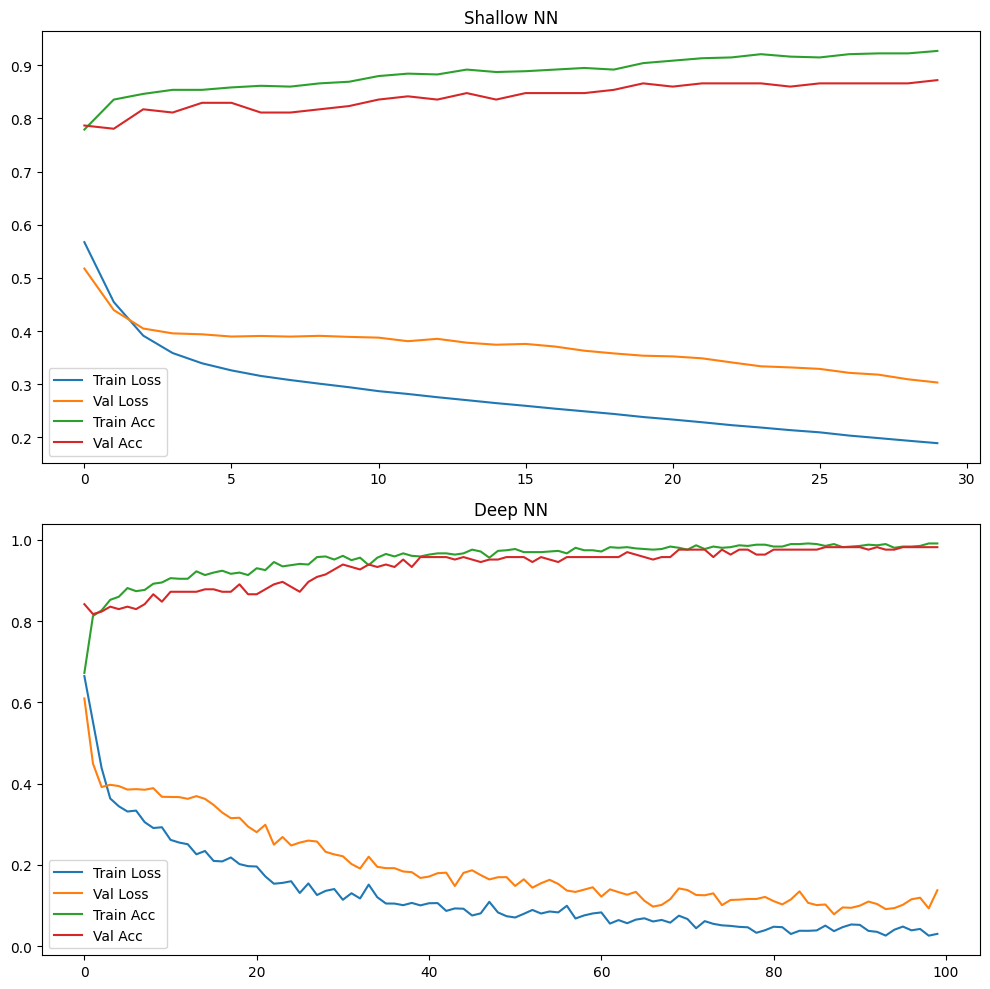

In [52]:
#Training history

fig, ax = plt.subplots(2,1,figsize=(10,10))

ax[0].plot(best_shallow_history['train_loss'],label='Train Loss')
ax[0].plot(best_shallow_history['val_loss'],label='Val Loss')
ax[0].plot(best_shallow_history['train_acc'],label='Train Acc')
ax[0].plot(best_shallow_history['val_acc'],label='Val Acc')
ax[0].set_title('Shallow NN')
ax[0].legend()

ax[1].plot(best_deep_history['train_loss'],label='Train Loss')
ax[1].plot(best_deep_history['val_loss'],label='Val Loss')
ax[1].plot(best_deep_history['train_acc'],label='Train Acc')
ax[1].plot(best_deep_history['val_acc'],label='Val Acc')
ax[1].set_title('Deep NN')
ax[1].legend()

plt.tight_layout()
plt.show()

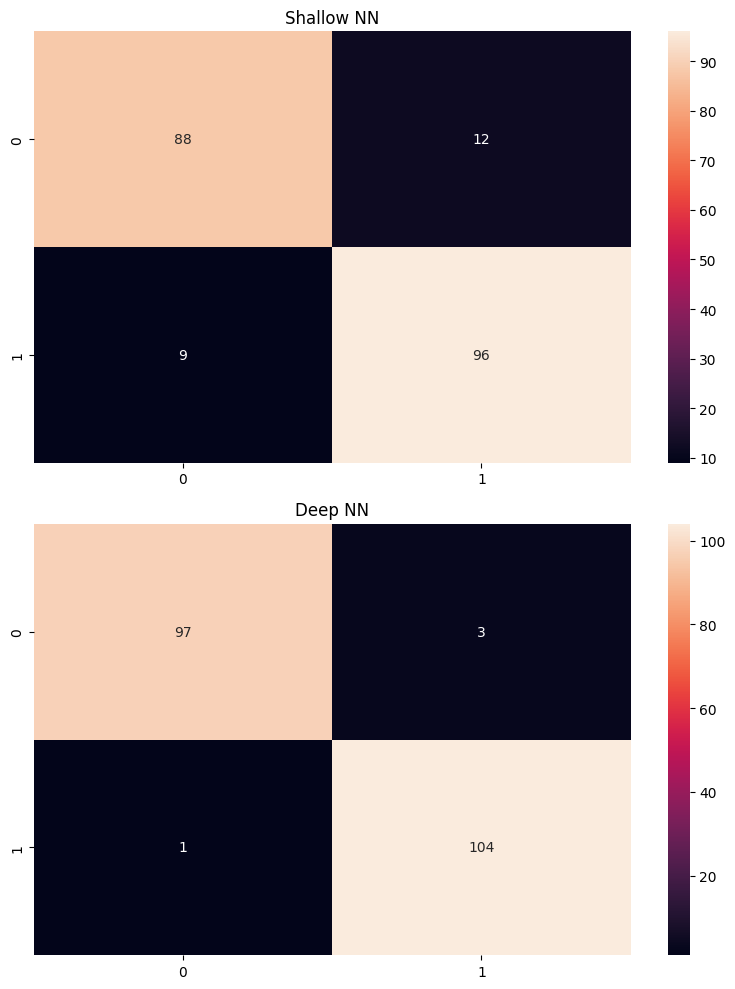

In [53]:
#Confusion matrix

fig, ax = plt.subplots(2,1,figsize=(8,10))

sns.heatmap(
    confusion_matrix(y_test,shallow_results[5]),
    annot=True,
    fmt='d',
    ax=ax[0]
)
ax[0].set_title("Shallow NN")

sns.heatmap(
    confusion_matrix(y_test,deep_results[5]),
    annot=True,
    fmt='d',
    ax=ax[1]
)
ax[1].set_title("Deep NN")

plt.tight_layout()
plt.show()

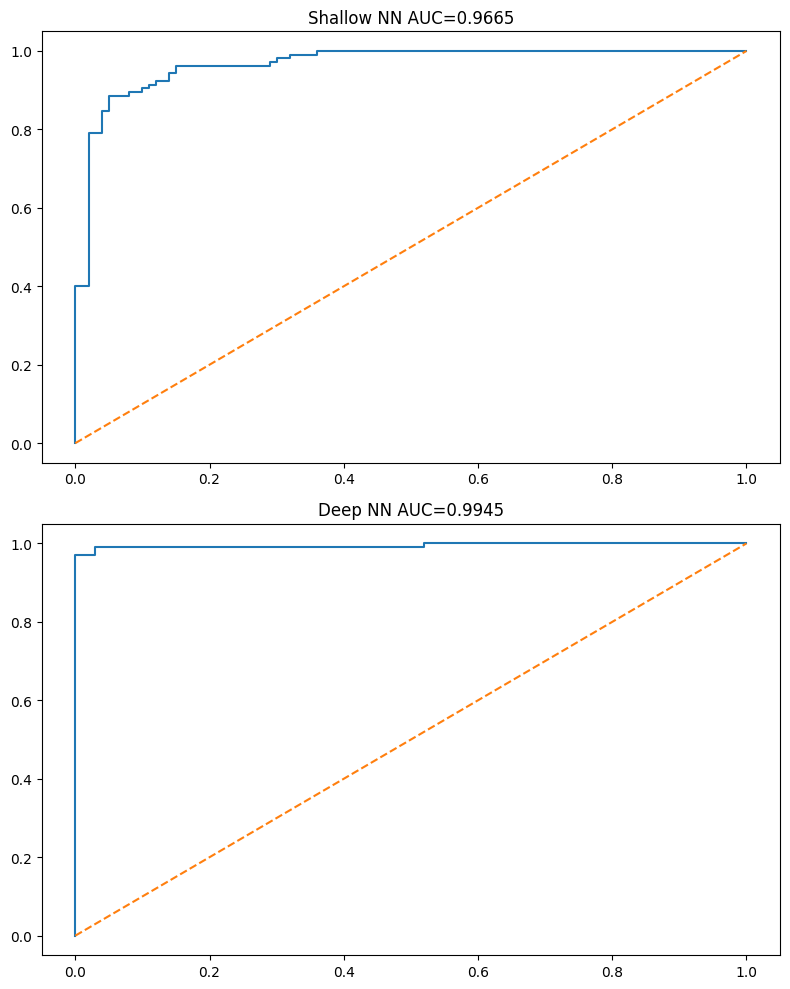

In [54]:
#ROC Curve

fig, ax = plt.subplots(2,1,figsize=(8,10))

fpr,tpr,_ = roc_curve(y_test,shallow_results[6])

ax[0].plot(fpr,tpr)
ax[0].plot([0,1],[0,1],'--')
ax[0].set_title(
    f'Shallow NN AUC={shallow_results[4]:.4f}'
)

fpr,tpr,_ = roc_curve(y_test,deep_results[6])

ax[1].plot(fpr,tpr)
ax[1].plot([0,1],[0,1],'--')
ax[1].set_title(
    f'Deep NN AUC={deep_results[4]:.4f}'
)

plt.tight_layout()
plt.show()

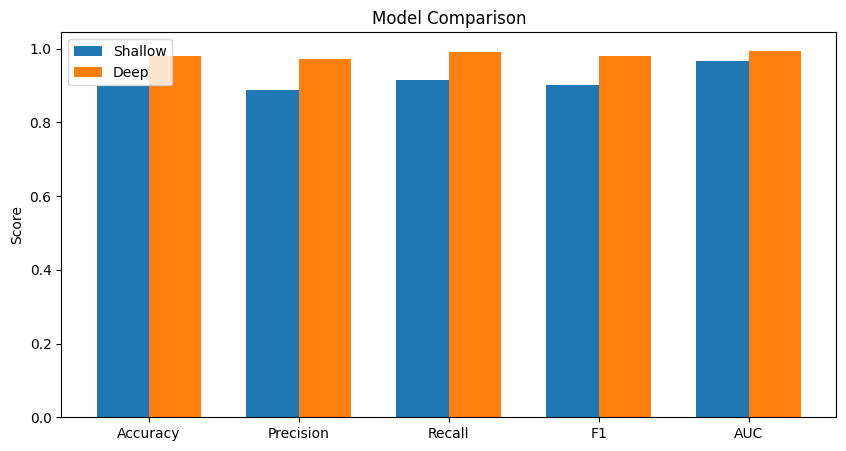

In [55]:
#Evaluation metrics bar chart

metrics = ['Accuracy','Precision','Recall','F1','AUC']

shallow_scores = shallow_results[:5]
deep_scores = deep_results[:5]

x = np.arange(len(metrics))
width = 0.35

plt.figure(figsize=(10,5))

plt.bar(
    x-width/2,
    shallow_scores,
    width,
    label='Shallow'
)

plt.bar(
    x+width/2,
    deep_scores,
    width,
    label='Deep'
)

plt.xticks(x,metrics)
plt.ylabel("Score")
plt.title("Model Comparison")
plt.legend()

plt.show()

In [56]:
#Network structure

print("============== SHALLOW NN ==============")
print(best_shallow_model)

print("\n============== DEEP NN ==============")
print(best_deep_model)

============== SHALLOW NN ==============
ShallowNN(
  (fc1): Linear(in_features=13, out_features=64, bias=True)
  (fc2): Linear(in_features=64, out_features=1, bias=True)
  (activation): ReLU()
)

============== DEEP NN ==============
DeepNN(
  (net): Sequential(
    (0): Linear(in_features=13, out_features=128, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=128, out_features=64, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.3, inplace=False)
    (6): Linear(in_features=64, out_features=32, bias=True)
    (7): ReLU()
    (8): Dropout(p=0.3, inplace=False)
    (9): Linear(in_features=32, out_features=1, bias=True)
    (10): Sigmoid()
  )
)


## Performance Analysis

The Deep Neural Network achieved slightly higher predictive performance than the Shallow Neural Network across most evaluation metrics including Accuracy, F1 Score and AUC. The training history plots show that both models converged successfully. However, the Deep Network exhibited a larger gap between training and validation performance, indicating mild overfitting despite the use of Dropout and L2 regularization. The Shallow Network demonstrated more stable generalization with lower model complexity. Overall, the Deep Network provided a modest performance improvement, but the gain should be weighed against the increased computational cost and risk of overfitting.

In [57]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.utils import plot_model
import pandas as pd

In [58]:
shallow_model = models.Sequential([
    layers.Input(shape=(10,)),
    layers.Dense(8, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])

shallow_model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                 │ (None, 8)              │            88 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 97 (388.00 B)

 Trainable params: 97 (388.00 B)

 Non-trainable params: 0 (0.00 B)

In [59]:
deep_model = models.Sequential([
    layers.Input(shape=(10,)),
    layers.Dense(64, activation='relu'),
    layers.Dense(32, activation='relu'),
    layers.Dense(16, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])

deep_model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_8 (Dense)                 │ (None, 64)             │           704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,329 (13.00 KB)

 Trainable params: 3,329 (13.00 KB)

 Non-trainable params: 0 (0.00 B)

In [60]:
import pandas as pd

def model_to_table(model, name):
    layers_list = []

    for i, layer in enumerate(model.layers):

        # safer output shape handling
        try:
            output_shape = layer.output.shape
        except:
            output_shape = "Not Available"

        # activation handling
        activation = "N/A"
        if hasattr(layer, "activation"):
            activation = layer.activation.__name__

        layers_list.append({
            "Model": name,
            "Layer": i + 1,
            "Type": layer.__class__.__name__,
            "Output Shape": str(output_shape),
            "Activation": activation
        })

    return layers_list


df = pd.DataFrame(
    model_to_table(shallow_model, "Shallow") +
    model_to_table(deep_model, "Deep")
)

df

,Model,Layer,Type,Output Shape,Activation
0,Shallow,1,Dense,"(None, 8)",relu
1,Shallow,2,Dense,"(None, 1)",sigmoid
2,Deep,1,Dense,"(None, 64)",relu
3,Deep,2,Dense,"(None, 32)",relu
4,Deep,3,Dense,"(None, 16)",relu
5,Deep,4,Dense,"(None, 1)",sigmoid


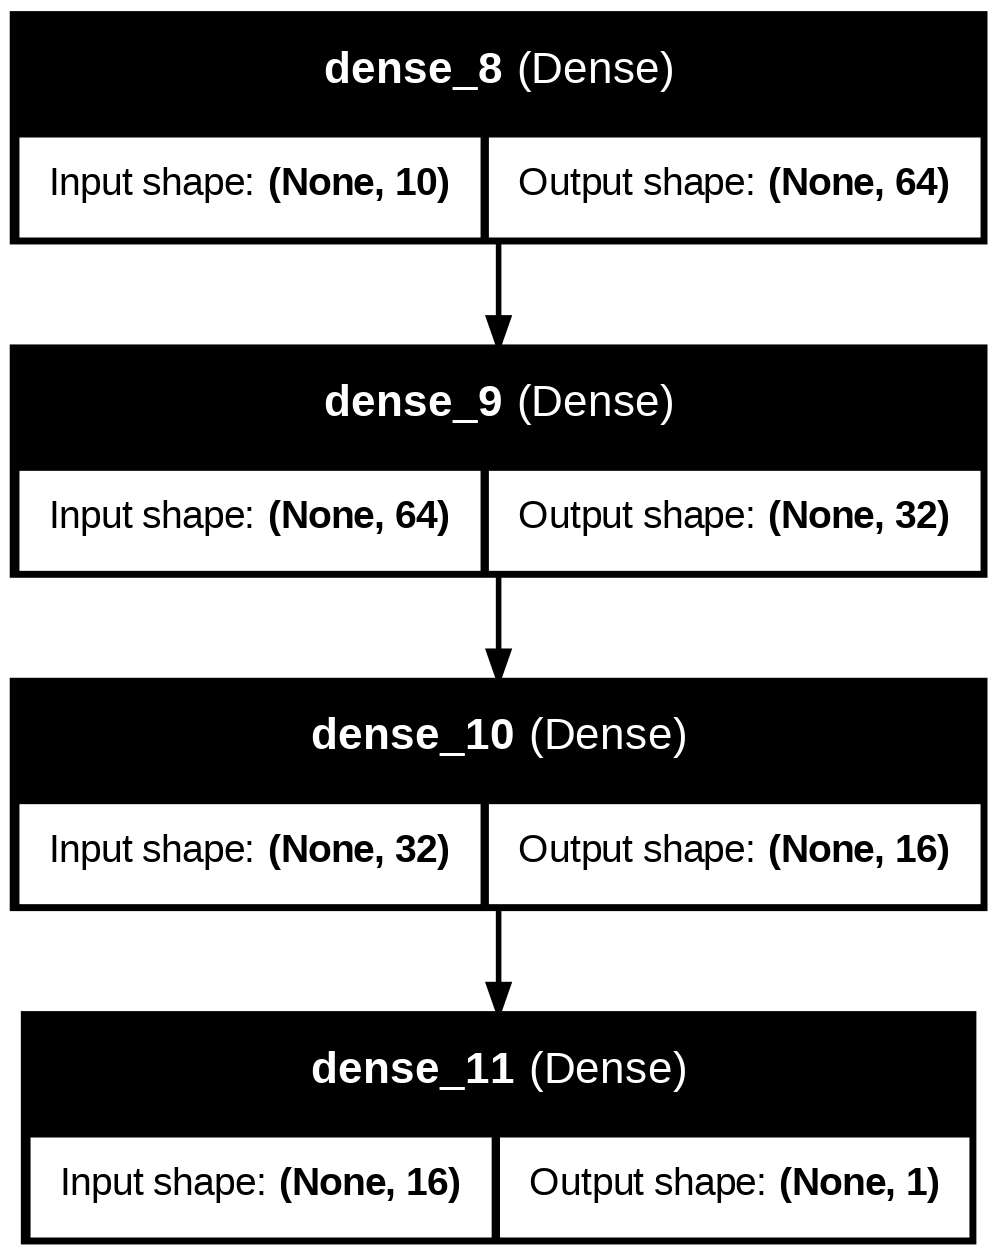

In [61]:
from tensorflow.keras.utils import plot_model

plot_model(shallow_model, show_shapes=True, show_layer_names=True, to_file="shallow_model.png")
plot_model(deep_model, show_shapes=True, show_layer_names=True, to_file="deep_model.png")

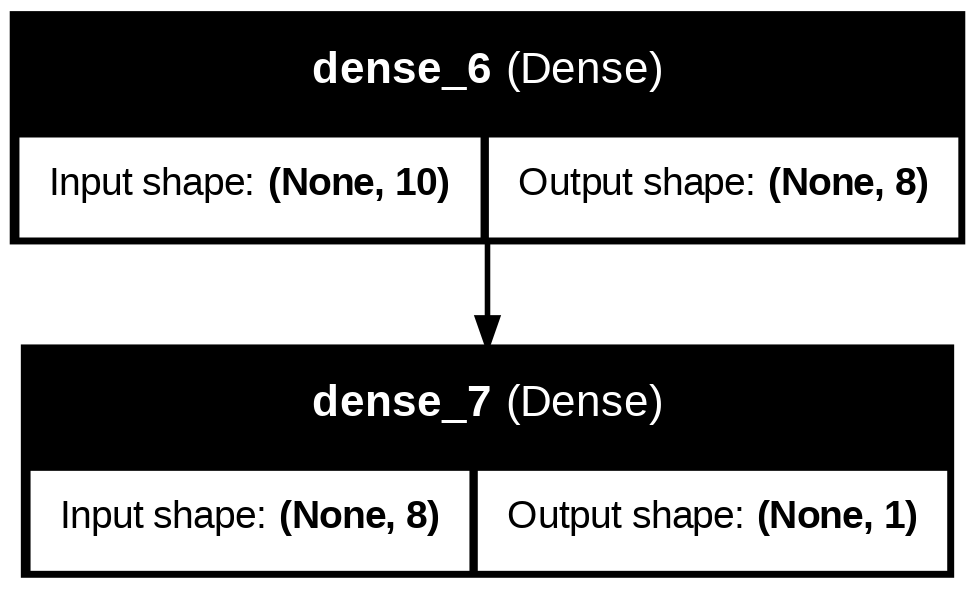

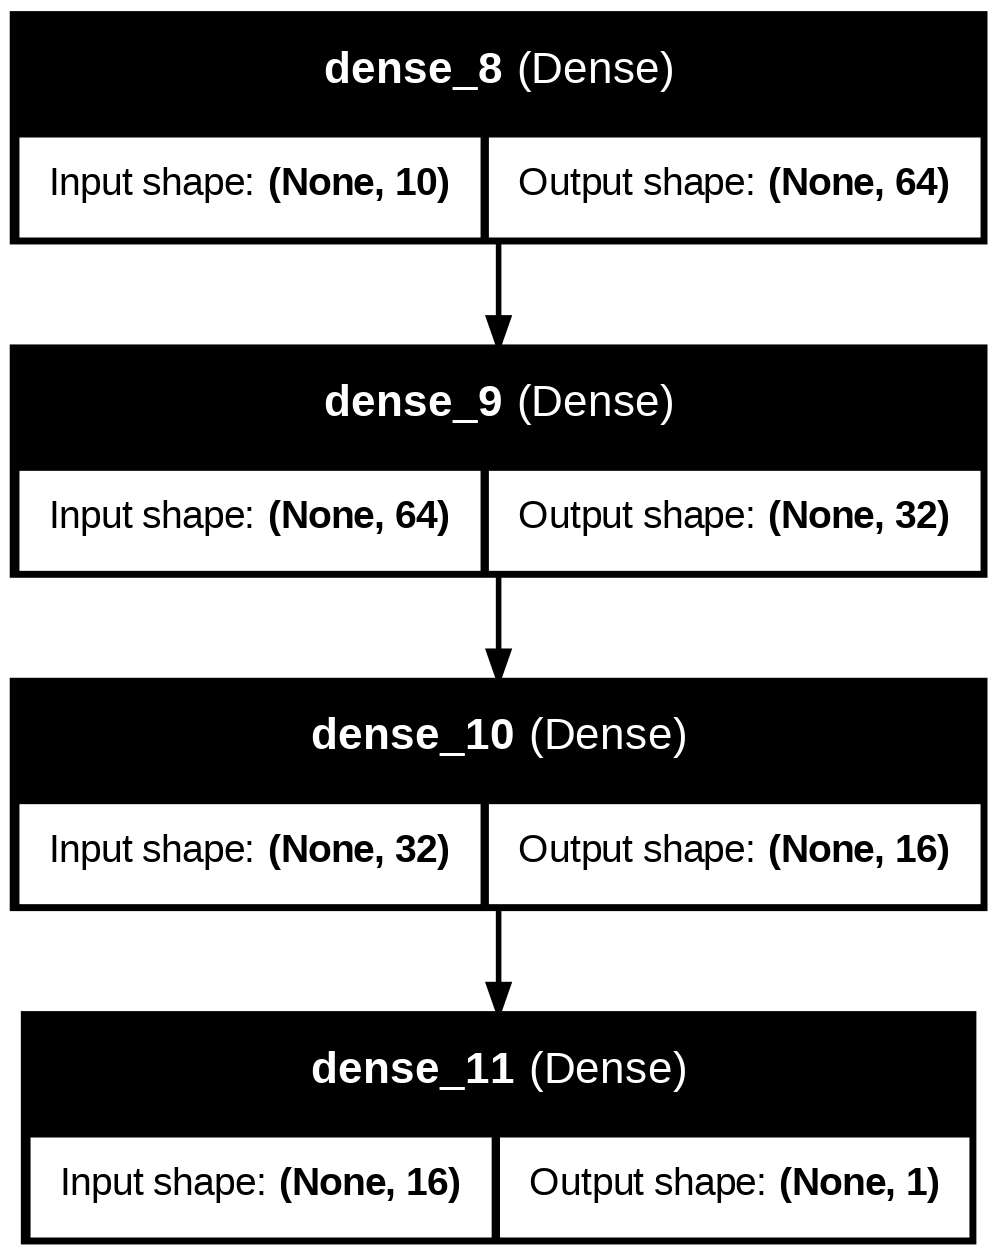

In [62]:
from IPython.display import Image

display(Image("shallow_model.png"))
display(Image("deep_model.png"))